# **Shinkansen Travel Experience**

### Project Overview

The project uses Shinkansen Bullet Train travel and passenger survey data to predict if a passenger reported a positive overall experience. The dataset includes two main sources of information: travel-related variables such as passenger type, travel class, distance, and delays, and survey-based experience variables, such as seat comfort, onboard entertainment, booking experience, cleanliness, and service quality.

The goal of the project is to both build an accurate classification model and understand which factors are most associated with passenger satisfaction. The workflow consists of data loading, merging, quality checks, exploratory analysis, missing-value treatment, feature engineering, baseline modeling, advanced tuning, CatBoost modeling, cross-validation, feature importance analysis, and final submission generation.

CatBoost was chosen as the final model because it achieved the strongest validation performance. The final model achieved approximately 95.7% validation accuracy and an F1 score of approximately 0.961.

### Problem Definition

The problem is to predict if a Shinkansen passenger had a positive overall experience. The target variable is Overall_Experience, where a value of 1 represents a positive experience and a value of 0 represents a negative experience.

As a binary classification problem, the model must learn patterns from the training data and predict the Overall_Experience of the passengers in the test data. The project also aims to identify which variables are the most important in shaping passenger satisfaction.

Another goal of the project is to compare an operational-only model against a full experience-driver model. The operational-only model uses variables such as age, customer type, travel class, distance, and delays. The full experience-driver model uses both operational variables and survey-based service-quality variables. The comparison helps to determine if satisfaction can be explained mostly by travel logistics or if comfort and service experience are stronger drivers.

### Import & Install Libraries

Reasoning: This makes sure everything runs in order.

In [ ]:
# Runtime -> Restart and run all

Reasoning: This prepares the notebook enviroment by installing all libraries needed for data handling, visualization, preprocessing, model training, model tuning and evaluation.

In [1]:
!pip install catboost -q

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


Interpretation: The notebook is ready for the project. The imported tools cover manupulation with pandas and NumPy, visualization with Matplotlib and Seaborn, preprocessing with scikit-learn pipelines, model training with Logistic Regression, Decision Tree, Random Forest, HistGradientBoosting, XGBoost, CatBoost, and evaluation using accuracy, precision, recall, F1 score, classification reports, and confusion matrices.

### Google Drive Mount

Reasoning: Connecting Google Colab to Google Drive ensures the notebook can access the training and test CSV files.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Interpretation: The drive was mounted successfully and the notebook can access the dataset files from the drive paths.

### Loading Training & Test Files

Reasoning: This loads the four source files: travel training data, survey training data, travel test data, and survey test data.

In [3]:
travel_train = pd.read_csv("/content/drive/MyDrive/Traveldata_train.csv")
survey_train = pd.read_csv("/content/drive/MyDrive/Surveydata_train.csv")

travel_test = pd.read_csv("/content/drive/MyDrive/Traveldata_test.csv")
survey_test = pd.read_csv("/content/drive/MyDrive/Surveydata_test.csv")

print("Travel train shape:", travel_train.shape)
print("Survey train shape:", survey_train.shape)
print("Travel test shape:", travel_test.shape)
print("Survey test shape:", survey_test.shape)

Travel train shape: (94379, 9)
Survey train shape: (94379, 17)
Travel test shape: (35602, 9)
Survey test shape: (35602, 16)


Interpretation: The training travel and survey files each contain 93,379 rows. The test travel and survey files each contain 35,602 rows. There is one more column in the survey training file than the survey test file (Overall_Experience).

### Merging Travel & Survey Data

Reasoning: This will merge the travel and survey datasets using shared ID column. The model needs both operational travel informatino and passenger survey responses to predict overall experience.

In [4]:
train_data = pd.merge(
    travel_train,
    survey_train,
    on="ID",
    how="inner"
)

test_data = pd.merge(
    travel_test,
    survey_test,
    on="ID",
    how="inner"
)

print("Merged training data shape:", train_data.shape)
print("Merged test data shape:", test_data.shape)

train_data.head()

Merged training data shape: (94379, 25)
Merged test data shape: (35602, 24)


,ID,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Overall_Experience,...,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
0,98800001,Female,Loyal Customer,52.0,NaN,Business,272,0.0,5.0,0,...,Good,Needs Improvement,Acceptable,Needs Improvement,Needs Improvement,Acceptable,Needs Improvement,Good,Needs Improvement,Poor
1,98800002,Male,Loyal Customer,48.0,Personal Travel,Eco,2200,9.0,0.0,0,...,Good,Poor,Good,Good,Excellent,Needs Improvement,Poor,Needs Improvement,Good,Good
2,98800003,Female,Loyal Customer,43.0,Business Travel,Business,1061,77.0,119.0,1,...,Needs Improvement,Good,Excellent,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Excellent
3,98800004,Female,Loyal Customer,44.0,Business Travel,Business,780,13.0,18.0,0,...,Acceptable,Needs Improvement,Acceptable,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Acceptable
4,98800005,Female,Loyal Customer,50.0,Business Travel,Business,1981,0.0,0.0,1,...,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Good,Good


Interpretation: The merged training dataset has 25 columns because it includes the target variable (Overall_Experience).  The merged test dataset has 24 columns. The target is not included and must be predicted. Each passenger record includes demographic, travel, delay, service, and satisfaction-related variables.

### Data Quality Checks

Reasoning: The section checks for duplicate rows, duplicate passenger ID's, and reviews the column names, data types, and missing-value counts. This ensures the dataset is structurally sound.

In [5]:
print("Duplicate rows in training data:", train_data.duplicated().sum())
print("Duplicate IDs in training data:", train_data["ID"].duplicated().sum())
print("Duplicate IDs in test data:", test_data["ID"].duplicated().sum())

train_data.info()

Duplicate rows in training data: 0
Duplicate IDs in training data: 0
Duplicate IDs in test data: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       94379 non-null  int64  
 1   Gender                   94302 non-null  object 
 2   Customer_Type            85428 non-null  object 
 3   Age                      94346 non-null  float64
 4   Type_Travel              85153 non-null  object 
 5   Travel_Class             94379 non-null  object 
 6   Travel_Distance          94379 non-null  int64  
 7   Departure_Delay_in_Mins  94322 non-null  float64
 8   Arrival_Delay_in_Mins    94022 non-null  float64
 9   Overall_Experience       94379 non-null  int64  
 10  Seat_Comfort             94318 non-null  object 
 11  Seat_Class               94379 non-null  object 
 12  Arrival_Time_Convenient  85449 

Interpretation: Each passenger ID appears only once. This is important because the final submission requires one prediction per ID. The infor whous the output of the dataset contains both numeric and categorical variables, and several columns have missing values. This shows that preprocessing and imputation are necessary before modeling.

### Separate Features, Target, and Test IDs

Reasoning: The code seperates the target variable from the input features and stores the test ID's for the final submission. The ID column is removed from the model training because it is not meaningful.

In [6]:
target = "Overall_Experience"

test_ids = test_data["ID"].copy()

X = train_data.drop(columns=[target, "ID"])
y = train_data[target]

X_test = test_data.drop(columns=["ID"])

print("Training feature shape:", X.shape)
print("Target shape:", y.shape)
print("Test feature shape:", X_test.shape)

Training feature shape: (94379, 23)
Target shape: (94379,)
Test feature shape: (35602, 23)


Interpretation: The training and test feature sets both have 23 columns after removing ID and the target. This means the model will train and predict using the same number of raw features.

### Target Distribution Counts

Reasoning: This will examine the distribution of the target variable (Overall_Experience). This helps to determine if the classification task is balanced or if class imbalance might aggect model evaluation.

In [7]:
target_counts = y.value_counts()
target_percentages = y.value_counts(normalize=True) * 100

print("Target Counts:")
print(target_counts)

print("\nTarget Percentages:")
print(target_percentages.round(2))

Target Counts:
Overall_Experience
1    51593
0    42786
Name: count, dtype: int64

Target Percentages:
Overall_Experience
1    54.67
0    45.33
Name: proportion, dtype: float64


Interpretation: The classes are reasonable balanced. There are slightly more positive experiences than negative. Accuracy is a useful metric, but precision, recall, and F1 score should also be reviered to ensure that the model performs well on both classes.

### Target Distribution Plot

Reasoning: The plot visualizes the target distribution so the balance between positive and negative passenger experiences can be inspected quickly. Visualizing the class balance makes the classification problem easier to understand.

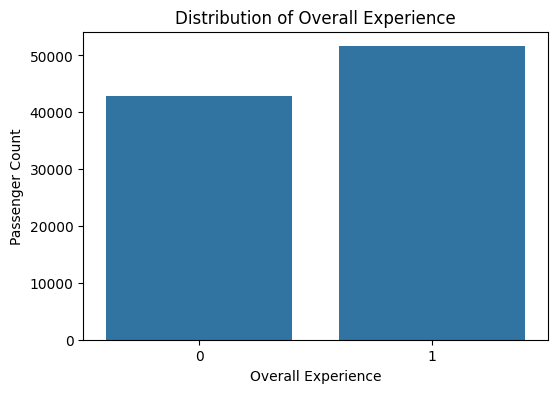

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribution of Overall Experience")
plt.xlabel("Overall Experience")
plt.ylabel("Passenger Count")
plt.show()

Interpretation: The count plot confirms that both classes are well represented. Class 1 appears more often than class 0. This supports using standard classification metrics.

### Missing Value Summary

Reasoning: This section calculates the number and percentage of missing values for each column. Models cannot handle missing data directly so this is important.

In [9]:
missing_summary = pd.DataFrame({
    "Missing_Count": train_data.isnull().sum(),
    "Missing_Percent": train_data.isnull().mean() * 100
})

missing_summary = missing_summary[missing_summary["Missing_Count"] > 0]
missing_summary = missing_summary.sort_values(by="Missing_Percent", ascending=False)

missing_summary

,Missing_Count,Missing_Percent
Type_Travel,9226,9.775480
Customer_Type,8951,9.484101
Arrival_Time_Convenient,8930,9.461851
Catering,8741,9.261594
Onboard_Service,7601,8.053698
Arrival_Delay_in_Mins,357,0.378262
Baggage_Handling,142,0.150457
Online_Support,91,0.096420
Legroom,90,0.095360
Gender,77,0.081586


Interpretation: Service and experience variables have meaningful missingness. Since these variables are likely predictive, dropping rows would remove valuable data.

### Missing Value Visualization

Reasoning: The chart visualizes the percentage of missing values by feature. A bar plot makes it easy to identify which variables need the most attention during preprocessing.

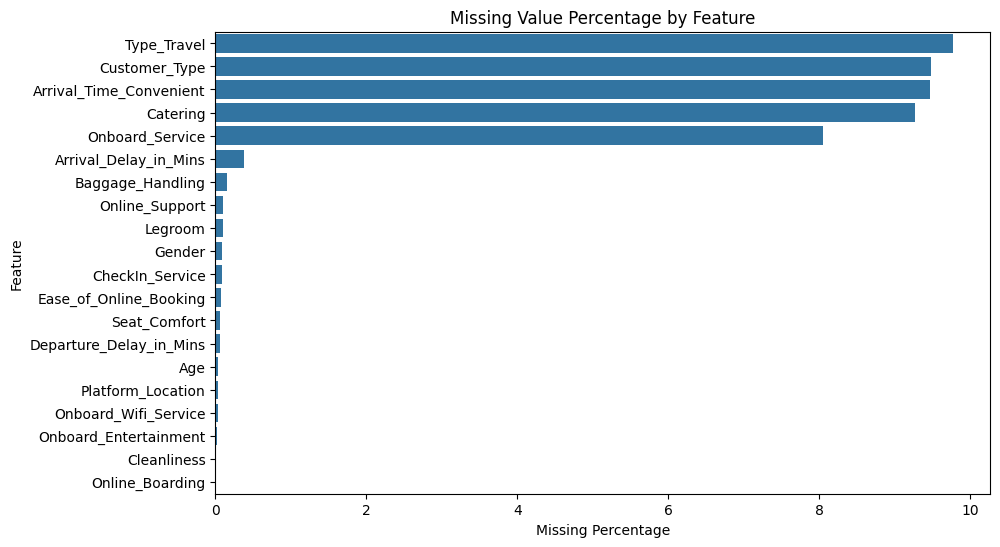

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=missing_summary.reset_index(),
    x="Missing_Percent",
    y="index"
)
plt.title("Missing Value Percentage by Feature")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.show()

Interpretation: The plot shows that Type_Travel, Customer_Type, Arrival_Time_Convenient, Catering, and Onboard_Service have the highest missing-value percentages. This supports using median imputation for numeric variables and missing categories for categorical variables.

### Categorical Feature Relationships with Target

Reasoning: This compares each categorical variable against the target variable using normalized crosstabs. The goal is identifying which categories are associated with positive or negative experiences.

In [11]:
categorical_cols = train_data.select_dtypes(include="object").columns.tolist()

if target in categorical_cols:
    categorical_cols.remove(target)

for col in categorical_cols:
    print("=" * 80)
    print(f"Overall Experience Percentage by {col}")

    table = pd.crosstab(
        train_data[col],
        train_data[target],
        normalize="index"
    ) * 100

    display(table.round(2))

Overall Experience Percentage by Gender


Overall_Experience,0,1
Gender,,
Female,34.79,65.21
Male,56.17,43.83


Overall Experience Percentage by Customer_Type


Overall_Experience,0,1
Customer_Type,,
Disloyal Customer,76.06,23.94
Loyal Customer,38.37,61.63


Overall Experience Percentage by Type_Travel


...

Overall_Experience,0,1
CheckIn_Service,,
Acceptable,43.38,56.62
Excellent,26.66,73.34
Extremely Poor,100.00,0.00
Good,42.50,57.50
Needs Improvement,66.71,33.29
Poor,68.01,31.99


Overall Experience Percentage by Cleanliness


Overall_Experience,0,1
Cleanliness,,
Acceptable,67.96,32.04
Excellent,27.13,72.87
Extremely Poor,100.00,0.00
Good,41.43,58.57
Needs Improvement,59.65,40.35
Poor,59.08,40.92


Overall Experience Percentage by Online_Boarding


Overall_Experience,0,1
Online_Boarding,,
Acceptable,45.05,54.95
Excellent,26.94,73.06
Extremely Poor,100.00,0.00
Good,34.74,65.26
Needs Improvement,71.92,28.08
Poor,73.92,26.08


Interpretation: Seat_Comfort is notably predictive, with some categoires showing very high positive experience rates. This suggests that categorical service and comfort variables are likely to be among the strongest predictors.

### Numeric Summary Statistics

Reasoning: This summerizes numeric variables using descriptive statistics like mean, standard deviation, minimum, quartiles, and maximum. This helps in identifying the scale, spread, and potential outliers in numeric features.

In [12]:
numeric_cols = train_data.select_dtypes(include=np.number).columns.tolist()

train_data[numeric_cols].describe()

,ID,Age,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Overall_Experience
count,9.437900e+04,94346.000000,94379.000000,94322.000000,94022.000000,94379.000000
mean,9.884719e+07,39.419647,1978.888185,14.647092,15.005222,0.546658
std,2.724501e+04,15.116632,1027.961019,38.138781,38.439409,0.497821
min,9.880000e+07,7.000000,50.000000,0.000000,0.000000,0.000000
25%,9.882360e+07,27.000000,1359.000000,0.000000,0.000000,0.000000
50%,9.884719e+07,40.000000,1923.000000,0.000000,0.000000,1.000000
75%,9.887078e+07,51.000000,2538.000000,12.000000,13.000000,1.000000
max,9.889438e+07,85.000000,6951.000000,1592.000000,1584.000000,1.000000


Interpretation: The delay variables are highly skewed. Most passengers have low or zero delay, but a small number of very large delays. This supports later creation of delayed-related engineered features like total delay, delay difference, and delay flags.

### Numeric Correlation Heatmap

Reasoning: The heatmap shows correlations between numeric variables. This helps to identify if predictors are strongly related to one another or to the target.

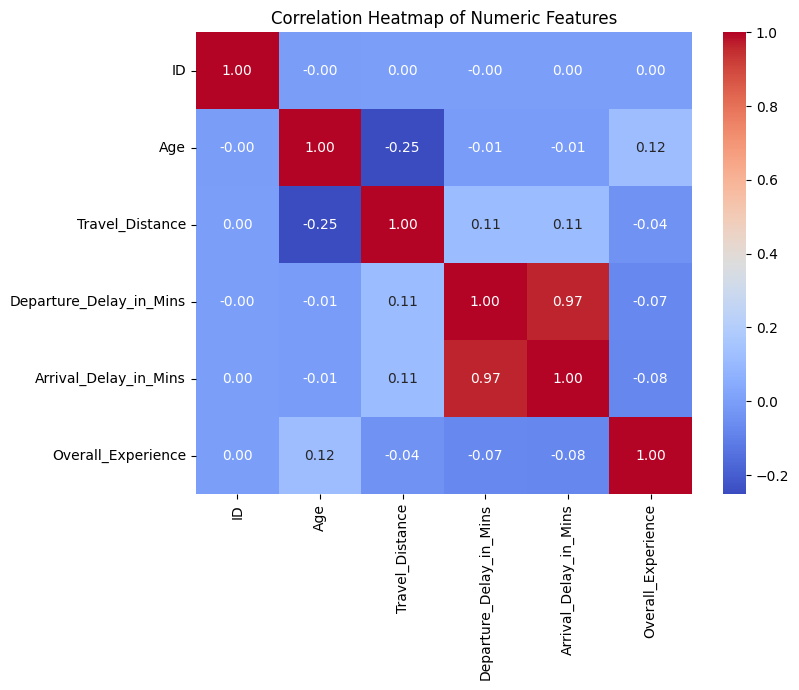

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    train_data[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

Interpretation: The heatmap shows a strong relationship between departure delay and arrival delay. Numeric values alone do not appear to fully explain Overall_Experience.

### Train-Validation Split

Reasoning: This splits the raw training data into training and validation sets before feature engineering.

In [14]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Raw training shape:", X_train_raw.shape)
print("Raw validation shape:", X_val_raw.shape)

Raw training shape: (75503, 23)
Raw validation shape: (18876, 23)


Interpretation: The split uses 80% of the data for training and 20% for validation. The use of stratify=y presearves the target distribution in both sets. This makes the validation more reliable and reduces leakage risk.

### Defining ShinkansenFeatureEngineer

Reasoning: This class creates engineered features for the passenger experience model. This is to prevent leakage by learning distance bins only from training and then applying those same bins to validation and test data.

In [15]:
class ShinkansenFeatureEngineer:

    def __init__(self):
        self.distance_bins_ = None

    def fit(self, X):
        X_copy = X.copy()

        _, self.distance_bins_ = pd.qcut(
            X_copy["Travel_Distance"],
            q=4,
            retbins=True,
            duplicates="drop"
        )

        return self

    def transform(self, X):
        df = X.copy()

        df["Departure_Delay_Missing"] = df["Departure_Delay_in_Mins"].isnull().astype(int)
        df["Arrival_Delay_Missing"] = df["Arrival_Delay_in_Mins"].isnull().astype(int)

        df["Total_Delay"] = (
            df["Departure_Delay_in_Mins"].fillna(0) +
            df["Arrival_Delay_in_Mins"].fillna(0)
        )

        df["Delay_Difference"] = (
            df["Arrival_Delay_in_Mins"].fillna(0) -
            df["Departure_Delay_in_Mins"].fillna(0)
        )

        df["Delay_Ratio"] = (
            df["Arrival_Delay_in_Mins"].fillna(0) /
            (df["Departure_Delay_in_Mins"].fillna(0) + 1)
        )

        df["Has_Departure_Delay"] = (
            df["Departure_Delay_in_Mins"].fillna(0) > 0
        ).astype(int)

        df["Has_Arrival_Delay"] = (
            df["Arrival_Delay_in_Mins"].fillna(0) > 0
        ).astype(int)

        df["Distance_Group"] = pd.cut(
            df["Travel_Distance"],
            bins=self.distance_bins_,
            labels=False,
            include_lowest=True
        )

        df["Distance_Group"] = df["Distance_Group"].fillna(-1).astype(int).astype(str)

        interaction_cols = [
            "Travel_Class",
            "Customer_Type",
            "Type_Travel",
            "Seat_Comfort",
            "Onboard_Entertainment",
            "Online_Support",
            "Ease_of_Online_Booking"
        ]

        for col in interaction_cols:
            if col in df.columns:
                df[col] = df[col].fillna("Missing").astype(str)

        df["Class_Customer_Interaction"] = (
            df["Travel_Class"].astype(str) + "_" +
            df["Customer_Type"].astype(str)
        )

        df["Class_TravelType_Interaction"] = (
            df["Travel_Class"].astype(str) + "_" +
            df["Type_Travel"].astype(str)
        )

        df["Seat_Entertainment_Interaction"] = (
            df["Seat_Comfort"].astype(str) + "_" +
            df["Onboard_Entertainment"].astype(str)
        )

        df["Online_Service_Interaction"] = (
            df["Online_Support"].astype(str) + "_" +
            df["Ease_of_Online_Booking"].astype(str)
        )

        return df

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

Interpretation: This is a strong improvement because the class seperates fit() and transform() behavior. This helps to ensure validation and test data are transformed using training derived rules.

### Applying Feature Engineering

Reasoning: This applies feature engineering class to the training, validation, and test sets. It is only fit on the training data, then used to transform validation and test data.

In [16]:
feature_engineer = ShinkansenFeatureEngineer()

X_train_eng = feature_engineer.fit_transform(X_train_raw)

X_val_eng = feature_engineer.transform(X_val_raw)
X_test_eng = feature_engineer.transform(X_test)

print("Engineered training shape:", X_train_eng.shape)
print("Engineered validation shape:", X_val_eng.shape)
print("Engineered test shape:", X_test_eng.shape)

Engineered training shape: (75503, 35)
Engineered validation shape: (18876, 35)
Engineered test shape: (35602, 35)


Interpretation: The raw feature increased from 23 to 35 columns, meaning 12 features were added. This is correct and consistent across training, validation, and test sets. The workflow is leakage-safe because validation and test feature engineering are based on training rules.

### Building Preprocessing Pipeline

Reasoning: The function builds a preprocessing pipeline for models that require numeric input. It handles numeric and categorical columns differently so that standard scikit-learn models and XGBoost can train properly.

In [17]:
def build_preprocessor(X):

    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    return preprocessor

Interpretation: The function is defined successfully. Numeric variables are imputed with the median and scaled. Categorical variables are imputed with "Missing" and one-hot encoded. This allows models such as Logistic Regression, Decision Tree, Random Forest, HistGradientBoosting, and XGBoost to use the mixed-type dataset.

### Building Baseline Models

Reasoning: This function creates several baseline models using the same preprocessing pipeline. Comparing multiple baseline models helps establish whether more complex algorithms provide meaningful improvement.

In [18]:
def build_baseline_models(preprocessor):

    models = {
        "Logistic Regression": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, random_state=42))
        ]),

        "Decision Tree": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", DecisionTreeClassifier(random_state=42))
        ]),

        "Random Forest": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "HistGradientBoosting": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", HistGradientBoostingClassifier(random_state=42))
        ])
    }

    return models

Interpretation: This is a good baseline set because it includes a linear model, a simple tree model, an ensemble tree model, and a boosting model.

### Defining Evaluation Function

Reasoning: This standardizes model evaluation. It fits a model, predicts on the validation set, and returns accuracy, precision, recall, and F1 score.

In [19]:
def evaluate_model(name, model, X_train, y_train, X_val, y_val):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1 Score": f1_score(y_val, y_pred)
    }

    return results, y_pred

Interpretation: This improves notebook organization because it avoids repeating evaluation code for each model. It also ensures that models are compared using the same metrics.

### Operational-Only Model Comparison

Reasoning: This section trains baseline models using only operational variables: demographic, travel, class, distance, and delay features. This creates a realistic baseline for what might be predicted before or during a trip without full survey feedback.

In [20]:
operational_features = [
    "Gender",
    "Customer_Type",
    "Age",
    "Type_Travel",
    "Travel_Class",
    "Travel_Distance",
    "Departure_Delay_in_Mins",
    "Arrival_Delay_in_Mins"
]

X_train_operational = X_train_raw[operational_features].copy()
X_val_operational = X_val_raw[operational_features].copy()

operational_preprocessor = build_preprocessor(X_train_operational)
operational_models = build_baseline_models(operational_preprocessor)

operational_results = []

for name, model in operational_models.items():
    print(f"Training {name}...")

    result, _ = evaluate_model(
        name,
        model,
        X_train_operational,
        y_train,
        X_val_operational,
        y_val
    )

    result["Model_Set"] = "Operational Only"
    operational_results.append(result)

operational_results_df = pd.DataFrame(operational_results).sort_values(
    by="Accuracy",
    ascending=False
)

operational_results_df

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training HistGradientBoosting...


,Model,Accuracy,Precision,Recall,F1 Score,Model_Set
3,HistGradientBoosting,0.791375,0.780928,0.859483,0.818324,Operational Only
2,Random Forest,0.753179,0.765279,0.791162,0.778005,Operational Only
0,Logistic Regression,0.747987,0.735439,0.841845,0.785053,Operational Only
1,Decision Tree,0.692732,0.720848,0.714701,0.717762,Operational Only


Interpretation: This shows that operational data has useful predictive value but is not enough to fully explain passenger satisfaction. The model can identify some patterns, but the accuracy is far below the full experience models. This is an important business insight: delays, distance, and travel class matter, but they do not capture the full passenger experience.

### Full Experience Baseline Model Comparison

Reasoning: This section trains baseline models using the full engineered feature set, including operational variables and passenger survey/service variables. This tests whether direct experience-related features improve prediction.

In [21]:
full_preprocessor = build_preprocessor(X_train_eng)
full_models = build_baseline_models(full_preprocessor)

full_results = []

for name, model in full_models.items():
    print(f"Training {name}...")

    result, _ = evaluate_model(
        name,
        model,
        X_train_eng,
        y_train,
        X_val_eng,
        y_val
    )

    result["Model_Set"] = "Full Experience"
    full_results.append(result)

full_results_df = pd.DataFrame(full_results).sort_values(
    by="Accuracy",
    ascending=False
)

full_results_df

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training HistGradientBoosting...


,Model,Accuracy,Precision,Recall,F1 Score,Model_Set
3,HistGradientBoosting,0.949195,0.960811,0.945634,0.953162,Full Experience
2,Random Forest,0.948983,0.959348,0.946797,0.953031,Full Experience
1,Decision Tree,0.928375,0.934406,0.934587,0.934496,Full Experience
0,Logistic Regression,0.907131,0.918262,0.911232,0.914733,Full Experience


Interpretation: This is a major improvement over the operational-only model. Accuracy increases from about 79.1% to about 94.9%. This strongly suggests that satisfaction is driven much more by comfort, service quality, and survey-based experience variables than by travel logistics alone.

### Tuning HistGradientBoosting

Reasoning: This section tunes the HistGradientBoosting model using randomized search. Hyperparameter tuning is used to improve model performance beyond the default baseline settings.

In [22]:
hgb_preprocessor = build_preprocessor(X_train_eng)

hgb_pipeline = Pipeline(steps=[
    ("preprocessor", hgb_preprocessor),
    ("classifier", HistGradientBoostingClassifier(random_state=42))
])

hgb_param_grid = {
    "classifier__max_iter": [200, 300, 500],
    "classifier__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "classifier__max_leaf_nodes": [15, 31, 63],
    "classifier__l2_regularization": [0.0, 0.01, 0.1, 1.0],
    "classifier__min_samples_leaf": [10, 20, 30]
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_param_grid,
    n_iter=20,
    scoring="accuracy",
    cv=3,
    random_state=42,
    n_jobs=-1
)

hgb_search.fit(X_train_eng, y_train)

tuned_hgb_model = hgb_search.best_estimator_
y_pred_hgb = tuned_hgb_model.predict(X_val_eng)

print("Best HistGradientBoosting Parameters:")
print(hgb_search.best_params_)

print("\nTuned HistGradientBoosting Results")
print("Accuracy:", accuracy_score(y_val, y_pred_hgb))
print("Precision:", precision_score(y_val, y_pred_hgb))
print("Recall:", recall_score(y_val, y_pred_hgb))
print("F1 Score:", f1_score(y_val, y_pred_hgb))
print(classification_report(y_val, y_pred_hgb))

Best HistGradientBoosting Parameters:
{'classifier__min_samples_leaf': 20, 'classifier__max_leaf_nodes': 63, 'classifier__max_iter': 300, 'classifier__learning_rate': 0.08, 'classifier__l2_regularization': 0.0}

Tuned HistGradientBoosting Results
Accuracy: 0.9542805679169315
Precision: 0.9659046117461568
Recall: 0.9498982459540654
F1 Score: 0.9578345629550007
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8557
           1       0.97      0.95      0.96     10319

    accuracy                           0.95     18876
   macro avg       0.95      0.95      0.95     18876
weighted avg       0.95      0.95      0.95     18876



Interpretation: This improves over the full-experience baseline. The classification report shows strong performance for both classes, with overall accuracy around 95%. This confirms that tuning improves the model.

### Tuning XGBoost

Reasoning: This section tunes XGBoost, a powerful gradient boosting model that often performs well on structured tabular datasets. Randomized search tests different combinations of tree depth, learning rate, estimators, sampling, and regularization-related parameters.

In [23]:
xgb_preprocessor = build_preprocessor(X_train_eng)

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", xgb_preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_grid = {
    "classifier__n_estimators": [300, 500, 700],
    "classifier__learning_rate": [0.03, 0.05, 0.08],
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__subsample": [0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=25,
    scoring="accuracy",
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_eng, y_train)

tuned_xgb_model = xgb_search.best_estimator_
y_pred_xgb = tuned_xgb_model.predict(X_val_eng)

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nTuned XGBoost Results")
print("Accuracy:", accuracy_score(y_val, y_pred_xgb))
print("Precision:", precision_score(y_val, y_pred_xgb))
print("Recall:", recall_score(y_val, y_pred_xgb))
print("F1 Score:", f1_score(y_val, y_pred_xgb))
print(classification_report(y_val, y_pred_xgb))

Best XGBoost Parameters:
{'classifier__subsample': 0.9, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 5, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.08, 'classifier__colsample_bytree': 1.0}

Tuned XGBoost Results
Accuracy: 0.9561877516422971
Precision: 0.9672179562906084
Recall: 0.9521271441031107
F1 Score: 0.9596132245934463
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8557
           1       0.97      0.95      0.96     10319

    accuracy                           0.96     18876
   macro avg       0.96      0.96      0.96     18876
weighted avg       0.96      0.96      0.96     18876



Interpretation: This is stronger than tuned HistGradientBoosting. XGBoost is now a serious final-model candidate, but it is later slightly outperformed by CatBoost.

### Defining CatBoostDataPreparer

Reasoning: This class prepares the engineered data for CatBoost. CatBoost can use categorical variables directly, but categorical columns must be properly filled and converted to string, and the categorical feature indices must be provided.

In [24]:
class CatBoostDataPreparer:

    def __init__(self):
        self.categorical_cols_ = None
        self.numeric_cols_ = None
        self.numeric_medians_ = None
        self.cat_feature_indices_ = None
        self.columns_ = None

    def fit(self, X):
        self.columns_ = X.columns.tolist()

        self.categorical_cols_ = X.select_dtypes(
            include=["object", "category"]
        ).columns.tolist()

        self.numeric_cols_ = X.select_dtypes(
            include=np.number
        ).columns.tolist()

        self.numeric_medians_ = X[self.numeric_cols_].median()

        self.cat_feature_indices_ = [
            X.columns.get_loc(col)
            for col in self.categorical_cols_
        ]

        return self

    def transform(self, X):
        X_prepared = X.copy()

        X_prepared = X_prepared[self.columns_]

        for col in self.categorical_cols_:
            X_prepared[col] = X_prepared[col].fillna("Missing").astype(str)

        for col in self.numeric_cols_:
            X_prepared[col] = X_prepared[col].fillna(self.numeric_medians_[col])

        return X_prepared

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

Interpretation: This is a strong design because numeric medians are learned only from training data, and validation/test data are transformed using the same column order and preparation rules. This helps prevent leakage and feature mismatch.

### Training CatBoost Validation Model

Reasoning: This section trains CatBoost on the engineered training set and evaluates it on the validation set. CatBoost is a strong choice because the dataset contains many categorical passenger-experience variables. Early stopping is used with a validation set to identify the best iteration.

In [25]:
cat_preparer = CatBoostDataPreparer()

X_train_cat = cat_preparer.fit_transform(X_train_eng)

X_val_cat = cat_preparer.transform(X_val_eng)

cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=7,
    l2_leaf_reg=3,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100,
    od_type="Iter",
    od_wait=100
)

cat_model.fit(
    X_train_cat,
    y_train,
    cat_features=cat_preparer.cat_feature_indices_,
    eval_set=(X_val_cat, y_val),
    use_best_model=True
)

y_pred_cat = cat_model.predict(X_val_cat)

cat_accuracy = accuracy_score(y_val, y_pred_cat)
cat_precision = precision_score(y_val, y_pred_cat)
cat_recall = recall_score(y_val, y_pred_cat)
cat_f1 = f1_score(y_val, y_pred_cat)

print("CatBoost Results")
print("Accuracy:", cat_accuracy)
print("Precision:", cat_precision)
print("Recall:", cat_recall)
print("F1 Score:", cat_f1)
print("Best iteration:", cat_model.get_best_iteration())
print(classification_report(y_val, y_pred_cat))

0:	learn: 0.8911699	test: 0.8884298	best: 0.8884298 (0)	total: 405ms	remaining: 13m 28s
100:	learn: 0.9437903	test: 0.9398707	best: 0.9398707 (100)	total: 42.5s	remaining: 13m 18s
200:	learn: 0.9526774	test: 0.9489828	best: 0.9489828 (200)	total: 1m 25s	remaining: 12m 48s
300:	learn: 0.9564123	test: 0.9517377	best: 0.9517377 (300)	total: 2m 8s	remaining: 12m 5s
400:	learn: 0.9590877	test: 0.9534859	best: 0.9534859 (400)	total: 2m 50s	remaining: 11m 21s
500:	learn: 0.9610479	test: 0.9547574	best: 0.9547574 (500)	total: 3m 34s	remaining: 10m 40s
600:	learn: 0.9623988	test: 0.9560288	best: 0.9560288 (600)	total: 4m 17s	remaining: 9m 58s
700:	learn: 0.9638690	test: 0.9568235	best: 0.9570354 (696)	total: 5m	remaining: 9m 16s
800:	learn: 0.9651272	test: 0.9568235	best: 0.9571943 (722)	total: 5m 44s	remaining: 8m 35s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9571943208
bestIteration = 722

Shrink model to first 723 iterations.
CatBoost Results
Accuracy: 0.9571943208

Interpretation: CatBoost achieved the strongest validation performance with approximately 95.7% Accuracy and a F1 Score 0.961%. This performance slightly exceeded XGBoost and HistGradientBoosting. CatBoost's native handling of categorical variables variable likely contributed to its superior performance.

### CatBoost Confusion Matrix

Reasoning: This creates a confusion matrix for the CatBoost validation predictions. The confusion matrix shows how many passengers were correctly and incorrectly classified in each class.

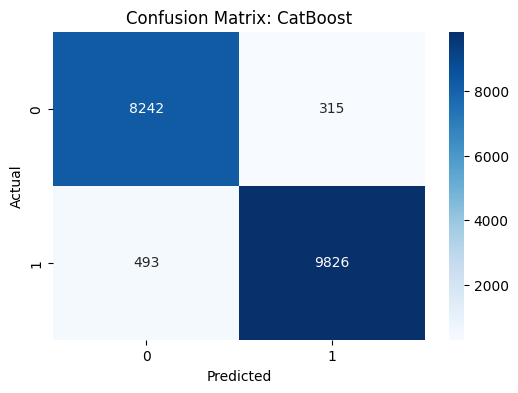

In [26]:
cm = confusion_matrix(y_val, y_pred_cat)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix: CatBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Interpretation: The plot displays the CatBoost confusion matrix. Most predictions should fall on the diagonal, which means the model correctly classifies most positive and negative experiences. This supports the high validation accuracy and F1 score reported in the model comparison table.

### Voting Ensemble

Reasoning: This section creates a soft voting ensemble from the tuned HistGradientBoosting and tuned XGBoost models. Soft voting averages predicted probabilities, which can sometimes improve performance over individual models.

In [27]:
voting_model = VotingClassifier(
    estimators=[
        ("hgb", tuned_hgb_model),
        ("xgb", tuned_xgb_model)
    ],
    voting="soft",
    n_jobs=-1
)

voting_model.fit(X_train_eng, y_train)

y_pred_vote = voting_model.predict(X_val_eng)

print("Voting Ensemble Results")
print("Accuracy:", accuracy_score(y_val, y_pred_vote))
print("Precision:", precision_score(y_val, y_pred_vote))
print("Recall:", recall_score(y_val, y_pred_vote))
print("F1 Score:", f1_score(y_val, y_pred_vote))
print(classification_report(y_val, y_pred_vote))

Voting Ensemble Results
Accuracy: 0.9558698876880695
Precision: 0.9677514792899409
Recall: 0.950964240721
F1 Score: 0.9592844225035436
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8557
           1       0.97      0.95      0.96     10319

    accuracy                           0.96     18876
   macro avg       0.95      0.96      0.96     18876
weighted avg       0.96      0.96      0.96     18876



Interpretation: The ensemble performs strongly but does not beat CatBoost or tuned XGBoost. This shows that ensembling helps produce competitive performance, but CatBoost remains the best model in this notebook.

### Model Comparison Table

Reasoning: This section compares the strongest models side by side using accuracy, precision, recall, and F1 score. This makes final model selection more transparent.

In [28]:
model_comparison = pd.DataFrame({
    "Model": [
        "Tuned HistGradientBoosting",
        "Tuned XGBoost",
        "Voting Ensemble",
        "CatBoost"
    ],
    "Accuracy": [
        accuracy_score(y_val, y_pred_hgb),
        accuracy_score(y_val, y_pred_xgb),
        accuracy_score(y_val, y_pred_vote),
        accuracy_score(y_val, y_pred_cat)
    ],
    "Precision": [
        precision_score(y_val, y_pred_hgb),
        precision_score(y_val, y_pred_xgb),
        precision_score(y_val, y_pred_vote),
        precision_score(y_val, y_pred_cat)
    ],
    "Recall": [
        recall_score(y_val, y_pred_hgb),
        recall_score(y_val, y_pred_xgb),
        recall_score(y_val, y_pred_vote),
        recall_score(y_val, y_pred_cat)
    ],
    "F1 Score": [
        f1_score(y_val, y_pred_hgb),
        f1_score(y_val, y_pred_xgb),
        f1_score(y_val, y_pred_vote),
        f1_score(y_val, y_pred_cat)
    ]
})

model_comparison = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
3,CatBoost,0.957194,0.968938,0.952224,0.960508
1,Tuned XGBoost,0.956188,0.967218,0.952127,0.959613
2,Voting Ensemble,0.955870,0.967751,0.950964,0.959284
0,Tuned HistGradientBoosting,0.954281,0.965905,0.949898,0.957835


Interpretation: CatBoost is the best model across accuracy and F1 score. The margin is not huge, but it is consistent enough to justify selecting CatBoost as the final model.

### Model Comparison Plot

Reasoning: This visualization displays validation accuracy for each advanced model. The plot makes it easier to communicate which model performed best.

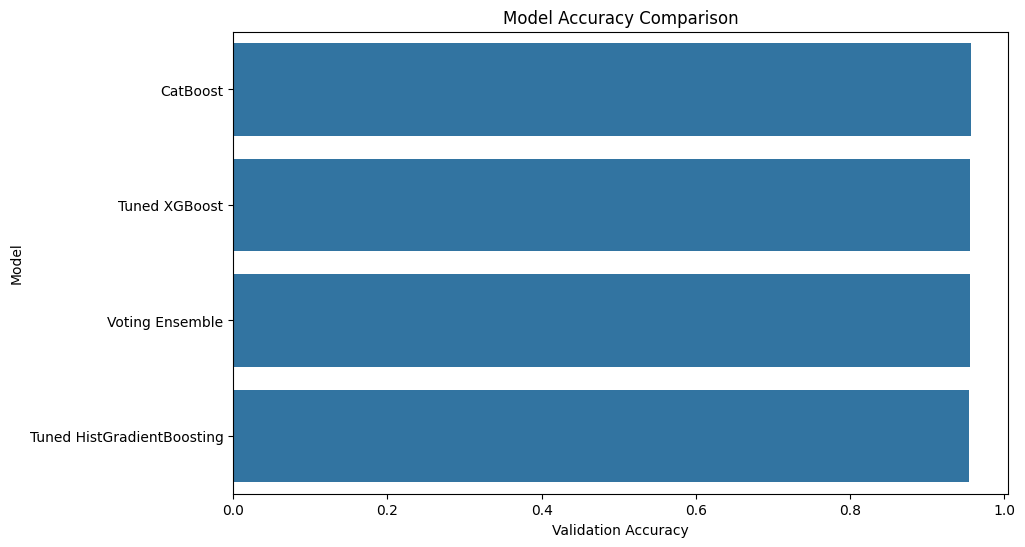

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=model_comparison,
    x="Accuracy",
    y="Model"
)
plt.title("Model Accuracy Comparison")
plt.xlabel("Validation Accuracy")
plt.ylabel("Model")
plt.show()

Interpretation: The plot shows CatBoost as the top-performing model, followed closely by tuned XGBoost and the voting ensemble. This supports the decision to select CatBoost as the final model.

### Final Model Selection

Reasoning: A clear final model selection step improves notebook readability and prevents confusion about whether the final model is CatBoost, XGBoost, or an ensemble.

In [30]:
final_model_name = "CatBoost"

print("Final selected model:", final_model_name)
print("Reason: CatBoost produced the strongest validation performance and handles categorical variables well.")

Final selected model: CatBoost
Reason: CatBoost produced the strongest validation performance and handles categorical variables well.


Interpretation: This is correct. CatBoost had the best validation accuracy and F1 score, and it is appropriate for this dataset because many important predictors are categorical service and survey variables.

### CatBoost Feature Importance Table

Reasoning: This extracts CatBoost feature importances and displays the top 20 features. Feature importance helps interpret what the model learned and connects model performance to business insight.

In [31]:
cat_feature_importance = pd.DataFrame({
    "Feature": X_train_cat.columns,
    "Importance": cat_model.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

cat_feature_importance.head(20)

,Feature,Importance
8,Seat_Comfort,17.989014
3,Type_Travel,9.897209
33,Seat_Entertainment_Interaction,8.085041
31,Class_Customer_Interaction,6.589453
16,Ease_of_Online_Booking,6.188187
12,Platform_Location,6.000051
14,Onboard_Entertainment,5.389265
0,Gender,5.098805
32,Class_TravelType_Interaction,4.914439
10,Arrival_Time_Convenient,3.555176


Interpretation: The model relies heavily on comfort, travel purpose, entertainment, booking experience, platform location, and interaction features. This supports the main business conclusion that passenger satisfaction is driven more by service quality and experience than by operational delays alone.

### Feature Importance Plot

Reasoning: This plot visualizes the top 20 CatBoost feature importances. A visual ranking is helpful for communicating the strongest satisfaction drivers to non-technical audiences.

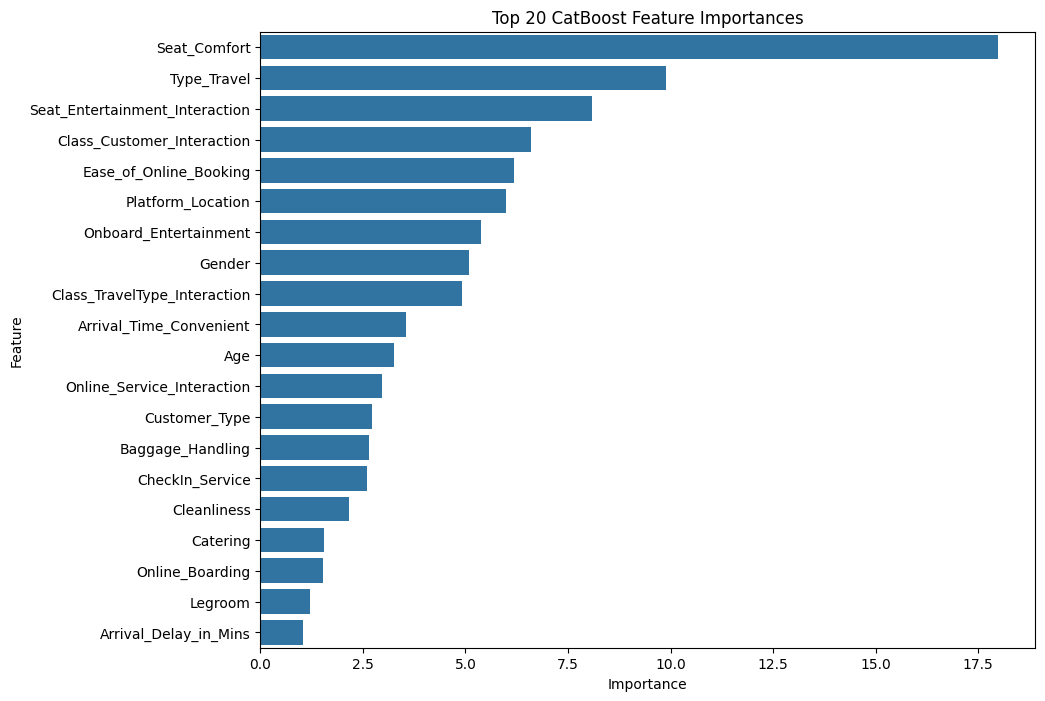

In [32]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=cat_feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 CatBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Interpretation: The plot confirms that Seat_Comfort is the strongest feature by a wide margin. Other important features include Type_Travel, Seat_Entertainment_Interaction, Class_Customer_Interaction, Ease_of_Online_Booking, Platform_Location, and Onboard_Entertainment.

### CatBoost Cross-Validation

Reasoning: This section performs 5-fold stratified cross-validation for CatBoost. Importantly, feature engineering and CatBoost preparation are refit inside each fold. This avoids leakage and provides a more reliable estimate of model stability.

In [33]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_accuracy_scores = []
cv_f1_scores = []
cv_best_iterations = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\nTraining fold {fold}...")

    X_train_fold_raw = X.iloc[train_idx].copy()
    X_val_fold_raw = X.iloc[val_idx].copy()
    y_train_fold = y.iloc[train_idx].copy()
    y_val_fold = y.iloc[val_idx].copy()

    fold_engineer = ShinkansenFeatureEngineer()
    X_train_fold_eng = fold_engineer.fit_transform(X_train_fold_raw)
    X_val_fold_eng = fold_engineer.transform(X_val_fold_raw)

    fold_preparer = CatBoostDataPreparer()
    X_train_fold_cat = fold_preparer.fit_transform(X_train_fold_eng)
    X_val_fold_cat = fold_preparer.transform(X_val_fold_eng)

    fold_model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.03,
        depth=7,
        l2_leaf_reg=3,
        loss_function="Logloss",
        eval_metric="Accuracy",
        random_seed=42,
        verbose=0,
        od_type="Iter",
        od_wait=100
    )

    fold_model.fit(
        X_train_fold_cat,
        y_train_fold,
        cat_features=fold_preparer.cat_feature_indices_,
        eval_set=(X_val_fold_cat, y_val_fold),
        use_best_model=True
    )

    y_pred_fold = fold_model.predict(X_val_fold_cat)

    fold_accuracy = accuracy_score(y_val_fold, y_pred_fold)
    fold_f1 = f1_score(y_val_fold, y_pred_fold)
    fold_best_iteration = fold_model.get_best_iteration()

    cv_accuracy_scores.append(fold_accuracy)
    cv_f1_scores.append(fold_f1)
    cv_best_iterations.append(fold_best_iteration)

    print(f"Fold {fold} Accuracy: {fold_accuracy:.4f}")
    print(f"Fold {fold} F1 Score: {fold_f1:.4f}")
    print(f"Fold {fold} Best Iteration: {fold_best_iteration}")

print("\nCross-Validation Accuracy Scores:", cv_accuracy_scores)
print("Mean Accuracy:", np.mean(cv_accuracy_scores))
print("Accuracy Standard Deviation:", np.std(cv_accuracy_scores))

print("\nCross-Validation F1 Scores:", cv_f1_scores)
print("Mean F1:", np.mean(cv_f1_scores))
print("F1 Standard Deviation:", np.std(cv_f1_scores))

print("\nBest Iterations:", cv_best_iterations)
print("Mean Best Iteration:", int(np.mean(cv_best_iterations)))


Training fold 1...
Fold 1 Accuracy: 0.9558
Fold 1 F1 Score: 0.9593
Fold 1 Best Iteration: 831

Training fold 2...
Fold 2 Accuracy: 0.9583
Fold 2 F1 Score: 0.9616
Fold 2 Best Iteration: 638

Training fold 3...
Fold 3 Accuracy: 0.9581
Fold 3 F1 Score: 0.9614
Fold 3 Best Iteration: 911

Training fold 4...
Fold 4 Accuracy: 0.9592
Fold 4 F1 Score: 0.9624
Fold 4 Best Iteration: 585

Training fold 5...
Fold 5 Accuracy: 0.9555
Fold 5 F1 Score: 0.9591
Fold 5 Best Iteration: 536

Cross-Validation Accuracy Scores: [0.9558169103623649, 0.9582538673447765, 0.9580949353676627, 0.9591544818817546, 0.9554966887417219]
Mean Accuracy: 0.9573633767396561
Accuracy Standard Deviation: 0.0014430725215174541

Cross-Validation F1 Scores: [0.9592534688293922, 0.9615572250951312, 0.9613939186880766, 0.9623773971600058, 0.9591121495327103]
Mean F1: 0.9607388318610631
F1 Standard Deviation: 0.0013142451223895817

Best Iterations: [831, 638, 911, 585, 536]
Mean Best Iteration: 700


Interpretation: The low standard deviation shows that CatBoost is stable across folds. The mean best iteration gives a defensible value for final model training.

### Selecting Final Iteration Count

Reasoning: This sets the final CatBoost iteration count using the mean best iteration from cross-validation. This is better than training for all 2000 iterations because it uses validation evidence to reduce overfitting risk.

In [34]:
best_iterations = int(np.mean(cv_best_iterations))

print("Using mean CV best iteration:", best_iterations)

Using mean CV best iteration: 700


Interpretation: The final model uses 700 iterations, which is based on cross-validation rather than guessing or blindly training for the maximum number of rounds.

### Fitting Final Feature Engineering on Full Training Data

Reasoning: This fits the feature engineering process on the full labeled training dataset. The same learned feature engineering rules are then applied to the test set.

In [35]:
final_feature_engineer = ShinkansenFeatureEngineer()

X_full_eng = final_feature_engineer.fit_transform(X)

X_test_final_eng = final_feature_engineer.transform(X_test)

print("Final engineered training shape:", X_full_eng.shape)
print("Final engineered test shape:", X_test_final_eng.shape)

Final engineered training shape: (94379, 35)
Final engineered test shape: (35602, 35)


Interpretation: This confirms that the final training and test datasets have matching engineered feature structures. This is correct and necessary before final model training and prediction.

### Preparing Full Data For Final CatBoost

Reasoning: This prepares the full engineered training and test datasets for CatBoost. It fits categorical and numeric preparation rules on the full training data, then applies those same rules to the test data.

In [36]:
final_cat_preparer = CatBoostDataPreparer()

X_full_cat = final_cat_preparer.fit_transform(X_full_eng)

X_test_cat = final_cat_preparer.transform(X_test_final_eng)

print("Final CatBoost training shape:", X_full_cat.shape)
print("Final CatBoost test shape:", X_test_cat.shape)

Final CatBoost training shape: (94379, 35)
Final CatBoost test shape: (35602, 35)


Interpretation: This confirms that the final CatBoost training and test matrices are aligned. The column order is preserved, missing values are handled, and categorical feature indices are available for CatBoost.

### Training Final CatBoost Model

Reasoning: This section trains the final CatBoost model on all labeled training data using the cross-validation-based iteration count. Training on the full dataset allows the model to use all available labeled examples before generating test predictions.

In [37]:
final_cat_model = CatBoostClassifier(
    iterations=best_iterations,
    learning_rate=0.03,
    depth=7,
    l2_leaf_reg=3,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

final_cat_model.fit(
    X_full_cat,
    y,
    cat_features=final_cat_preparer.cat_feature_indices_
)

0:	learn: 0.8896047	total: 404ms	remaining: 4m 42s
100:	learn: 0.9440977	total: 48.1s	remaining: 4m 45s
200:	learn: 0.9521186	total: 1m 36s	remaining: 4m
300:	learn: 0.9557953	total: 2m 25s	remaining: 3m 13s
400:	learn: 0.9588362	total: 3m 13s	remaining: 2m 24s
500:	learn: 0.9610083	total: 4m 1s	remaining: 1m 35s
600:	learn: 0.9622374	total: 4m 50s	remaining: 47.9s
699:	learn: 0.9635088	total: 5m 36s	remaining: 0us


CatBoostClassifier(depth=7, eval_metric='Accuracy', iterations=700, l2_leaf_reg=3, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

Interpretation: The training accuracy is higher than validation accuracy, but not wildly higher. Using 700 iterations helps control overfitting compared with training for all 2000 iterations.

### Generating Test Predictions

Reasoning: This uses the final trained CatBoost model to predict Overall_Experience for the test dataset. It then creates the final submission DataFrame with the required ID and Overall_Experience columns.

In [38]:
test_predictions = final_cat_model.predict(X_test_cat)

test_predictions = test_predictions.astype(int)

submission = pd.DataFrame({
    "ID": test_ids,
    "Overall_Experience": test_predictions
})

submission.head()

,ID,Overall_Experience
0,99900001,1
1,99900002,1
2,99900003,1
3,99900004,0
4,99900005,1


Interpretation: The prediction file has the correct structure. Each test passenger receives one predicted class.

### Final Results Summary

Reasoning: This section summarizes the full modeling progression, from operational-only baselines to the final CatBoost validation model. A final results table makes it easier to communicate how each modeling stage improved performance.

In [39]:
final_results_summary = pd.DataFrame({
    "Modeling Stage": [
        "Operational-Only Best Model",
        "Full Experience Baseline Best Model",
        "Tuned HistGradientBoosting",
        "Tuned XGBoost",
        "Voting Ensemble",
        "CatBoost Validation Model"
    ],
    "Validation Accuracy": [
        operational_results_df["Accuracy"].max(),
        full_results_df["Accuracy"].max(),
        accuracy_score(y_val, y_pred_hgb),
        accuracy_score(y_val, y_pred_xgb),
        accuracy_score(y_val, y_pred_vote),
        accuracy_score(y_val, y_pred_cat)
    ],
    "F1 Score": [
        operational_results_df["F1 Score"].max(),
        full_results_df["F1 Score"].max(),
        f1_score(y_val, y_pred_hgb),
        f1_score(y_val, y_pred_xgb),
        f1_score(y_val, y_pred_vote),
        f1_score(y_val, y_pred_cat)
    ]
})

final_results_summary = final_results_summary.sort_values(
    by="Validation Accuracy",
    ascending=False
)

final_results_summary

,Modeling Stage,Validation Accuracy,F1 Score
5,CatBoost Validation Model,0.957194,0.960508
3,Tuned XGBoost,0.956188,0.959613
4,Voting Ensemble,0.955870,0.959284
2,Tuned HistGradientBoosting,0.954281,0.957835
1,Full Experience Baseline Best Model,0.949195,0.953162
0,Operational-Only Best Model,0.791375,0.818324


Interpretation: The operational-only model provides a useful baseline, full experience variables greatly improve performance, tuned boosting models improve performance further, and CatBoost is the best final model.

### Validating Submission File

Reasoning: This validates the final submission file before saving. These checks help prevent common hackathon submission errors, such as missing predictions, duplicate IDs, incorrect column names, or invalid labels.

In [40]:
print("Submission shape:", submission.shape)

print("\nMissing values:")
print(submission.isnull().sum())

print("\nDuplicate IDs:", submission["ID"].duplicated().sum())

print("\nPrediction values:")
print(submission["Overall_Experience"].value_counts())

assert submission.shape[0] == test_data.shape[0], "Submission row count does not match test data."
assert list(submission.columns) == ["ID", "Overall_Experience"], "Submission columns are incorrect."
assert submission["Overall_Experience"].isnull().sum() == 0, "Submission contains missing predictions."
assert submission["ID"].duplicated().sum() == 0, "Submission contains duplicate IDs."
assert set(submission["Overall_Experience"].unique()).issubset({0, 1}), "Predictions must be only 0 or 1."

print("\nSubmission validation passed.")

Submission shape: (35602, 2)

Missing values:
ID                    0
Overall_Experience    0
dtype: int64

Duplicate IDs: 0

Prediction values:
Overall_Experience
1    19181
0    16421
Name: count, dtype: int64

Submission validation passed.


Interpretation: The submission has the correct number of rows, no missing values, no duplicate IDs, and only valid prediction labels.

### Saving Final Submission

Reasoning: This saves the final submission DataFrame as a CSV file. The index=False argument prevents pandas from adding an extra index column, which could cause submission formatting errors.

In [41]:
submission.to_csv("Final_Submission.csv", index=False)

print("Final_Submission.csv has been saved.")

Final_Submission.csv has been saved.


Interpretation: The final prediction file was created successfully.

### Conclusion

The project developed a machine-learning model to predict Shinkansen passenger overall experience using merged travel and survey data. The workflow included data loading, data merging, data quality checks, exploratory analysis, leakage-safe feature engineering, baseline modeling, advanced model tuning, CatBoost modeling, cross-validation, feature-importance analysis, final model training, and submission validation.

CatBoost was chosen as the final model because it achieved the strongest validation performance. The final model achieved approximately 95.7% validation accuracy and an F1 score of approximately 0.961. Cross-validation confirmed the model was stable across multiple folds, with a mean accuracy of approximately 95.7% and a low standard deviation. This suggests the model is not overly dependent on one particular train-validation split.

The results show that passenger satisfaction is driven more by comfort, service quality, entertainment, booking experience, travel type, and platform location than by operational travel variables alone. The operational model reached approximately 79% accuracy. The full experience-driver models reached roughly 95–96% accuracy. The large performance gap shows survey-based passenger experience variables contain much stronger predictive signal than delays, travel distance, and class information alone.

The final submission file was generated and passed validation checks for row count, missing values, duplicate IDs, required columns, and valid prediction labels.

### Business Recommendations

Passenger satisfaction appears to be influenced most strongly by comfort, service quality, travel type, entertainment, booking experience, and platform-related factors. The following recommendations could help improve passenger experience:

1. Prioritize seating comfort. Seat_Comfort was the strongest feature, suggesting that comfort has a major relationship with overall passenger satisfaction. Invest in seat quality, spacing, and cleanliness.

2. Improve onboard entertainment and service consistency. This includes seat comfort and entertainment. The findings suggest that the onboard environment matters beyond basic transportation performance.

3. Strengthen online booking and support experience. Improving booking usability, online support, and digital passenger communication may improve overall satisfaction.

4. Review platform-location and arrival-time convenience issues. Passenger experience may improve if wayfinding, platform accessibility, boarding convenience, and arrival timing are optimized.

5. Use different models for different purposes. The full CatBoost model is used for understanding satisfaction drivers when survey data is available. However, a separate operational-only model should be used when the goal is to predict dissatisfaction. This is because survey-based service ratings may not be available in real time.

6. Focus improvement efforts on the full passenger journey. The performance gap between the operational-only model and the full experience-driver model suggests that satisfaction is shaped by the entire passenger experience, not only by delays or travel distance. Service design, comfort, booking, platform experience, and onboard conditions should all be considered together.

### Limitations

There are several limitations for this project that are important to consider because the notebook focuses on model performance, while a real-world system would also require attention to timing, explainability, monitoring, and deployment readiness.

1. The strongest model uses survey-based service variables such as Seat_Comfort, Onboard_Entertainment, Ease_of_Online_Booking, Cleanliness, and Catering. In a real-world setting, some of these may only be known after a passenger has completed the trip and submitted feedback.

2. The CatBoost feature importance provides useful global insight, but does not fully explain individual predictions. Additional explainability tools like SHAP could provide deeper insight.

3. The engineered interaction features improved the model’s ability to capture combined effects, but interaction features should be carefully monitored in production because they can overfit to patterns in the training data.

4. The notebook focuses on predictive model performance and feature importance. Additional steps would be required for deployment. This would include model monitoring, data drift checks, retraining schedules, fairness review, and separation between features available before and after survey completion.